# Skew time-series analysis

Explore the historical behavior of the 30D, 60D, and 90D skew measures before choosing a forecasting model. This notebook uses the tested `build_daily_time_series()` function and SPX trading dates to apply the metric-specific QC flags, preserve missing sessions and values, and construct daily changes and tenor spreads. It does not fit forecasting models.

The currently available processed file may contain only part of the full historical sample. Check the loaded date count and date range below before interpreting the plots or statistics as representative of 2023–2025.

## Load and check the sample

Load the long-form CSV, then reshape it in memory. No new data file is written.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "time_series.py").exists()
)
sys.path.insert(0, str(project_root))
from src.time_series import build_daily_time_series, load_skew_metrics

metrics_path = project_root / "data/processed/spx_skew_metrics_2023_2025.csv"
spx_path = project_root / "data/raw/spx_security_prices.csv"
metrics_long = load_skew_metrics(metrics_path)
spx_prices = pd.read_csv(spx_path)
daily = build_daily_time_series(metrics_long, spx_prices)

sample_summary = pd.Series({
    "metric rows": len(metrics_long),
    "quote dates": metrics_long["quote_date"].nunique(),
    "first quote date": metrics_long["quote_date"].min().date(),
    "last quote date": metrics_long["quote_date"].max().date(),
})
display(sample_summary)
daily.head()

metric rows                219
quote dates                 73
first quote date    2023-01-03
last quote date     2023-04-18
dtype: object

,quote_date,skew_30,skew_60,skew_90,rr25_30,rr25_60,rr25_90,atm_iv_30,atm_iv_60,atm_iv_90,...,d_rr25_90,d_atm_iv_30,d_atm_iv_60,d_atm_iv_90,skew_30_60,skew_60_90,rr25_30_60,rr25_60_90,atm_iv_30_60,atm_iv_60_90
0,2023-01-03,0.268781,0.301584,0.300864,NaN,0.034525,0.043342,0.215388,0.210435,0.216370,...,NaN,NaN,NaN,NaN,-0.032803,0.000721,NaN,-0.008817,0.004953,-0.005935
1,2023-01-04,0.350692,0.280119,0.295845,0.028489,0.032175,0.041479,0.207514,0.203968,0.210078,...,-0.001863,-0.007875,-0.006467,-0.006293,0.070573,-0.015726,-0.003686,-0.009304,0.003545,-0.006109
2,2023-01-05,0.342158,0.304909,0.299725,0.028459,0.034483,0.042350,0.211933,0.205988,0.211634,...,0.000871,0.004420,0.002019,0.001556,0.037249,0.005184,-0.006024,-0.007867,0.005946,-0.005646
3,2023-01-06,0.325046,0.315801,0.306620,0.025185,0.033632,0.041325,0.196692,0.196570,0.201927,...,-0.001025,-0.015241,-0.009418,-0.009707,0.009245,0.009181,-0.008447,-0.007693,0.000123,-0.005358
4,2023-01-09,0.296271,0.334697,0.324352,0.023709,0.036798,0.044382,0.203774,0.202039,0.205350,...,0.003057,0.007082,0.005469,0.003423,-0.038426,0.010345,-0.013089,-0.007584,0.001736,-0.003312


## Skew levels through time

Plot all three tenor levels together. Look for changes in regime, persistence, and differences in variability by maturity. Gaps remain visible where QC rejected a metric.

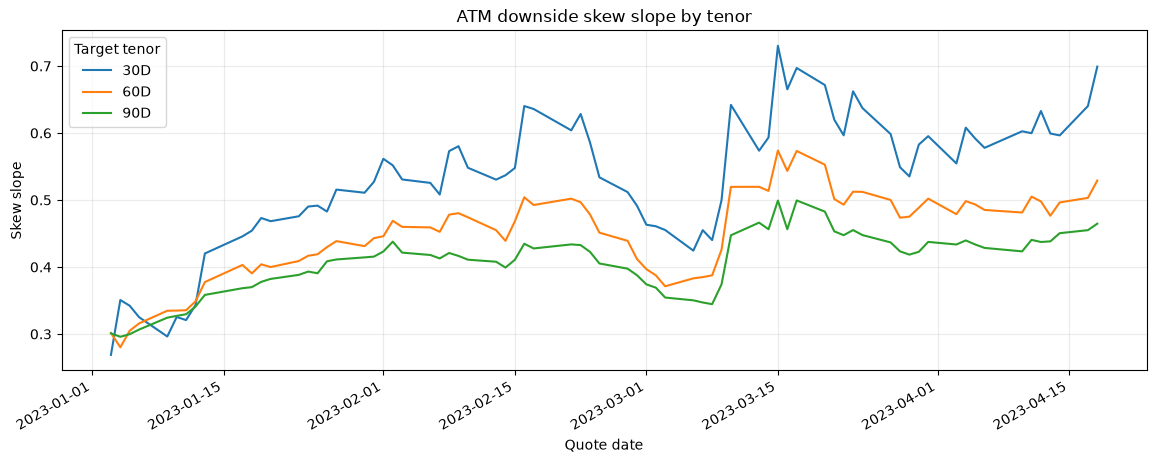

In [2]:
fig, ax = plt.subplots(figsize=(14, 5))
for tenor in (30, 60, 90):
    ax.plot(daily["quote_date"], daily[f"skew_{tenor}"], label=f"{tenor}D")
ax.set(title="ATM downside skew slope by tenor", xlabel="Quote date", ylabel="Skew slope")
ax.legend(title="Target tenor")
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.show()

## Daily skew changes

Changes are between adjacent quote-date rows. A missing skew observation makes the change on that date and the next observed change unavailable; the series is never forward-filled. Compare the size and frequency of spikes across tenors.

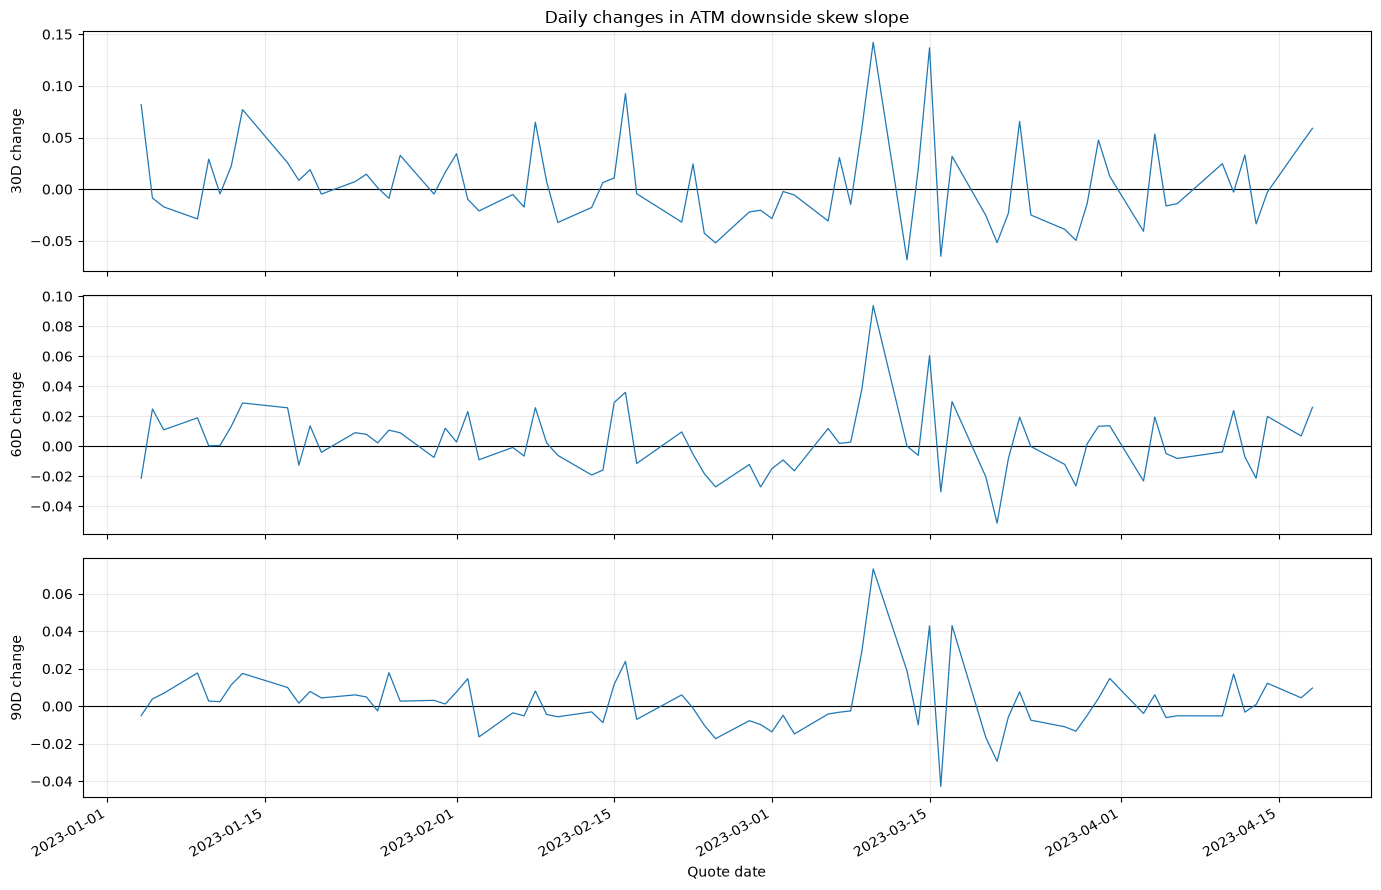

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, tenor in zip(axes, (30, 60, 90)):
    ax.axhline(0, color="black", linewidth=0.8)
    ax.plot(daily["quote_date"], daily[f"d_skew_{tenor}"], linewidth=0.9)
    ax.set_ylabel(f"{tenor}D change")
    ax.grid(alpha=0.25)
axes[0].set_title("Daily changes in ATM downside skew slope")
axes[-1].set_xlabel("Quote date")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Distributions

For each tenor, summarize both skew levels and daily changes. `n` counts finite observations, so the first change and changes adjacent to missing QC observations are excluded.

In [4]:
summary_rows = []
for tenor in (30, 60, 90):
    for kind, column in (("level", f"skew_{tenor}"), ("daily change", f"d_skew_{tenor}")):
        values = daily[column].dropna()
        summary_rows.append({
            "tenor": tenor, "series": kind, "n": values.size,
            "mean": values.mean(), "std": values.std(), "median": values.median(),
            "p05": values.quantile(0.05), "p25": values.quantile(0.25),
            "p75": values.quantile(0.75), "p95": values.quantile(0.95),
            "min": values.min(), "max": values.max(),
        })
distribution_summary = pd.DataFrame(summary_rows).set_index(["tenor", "series"])
distribution_summary

n      mean       std    median       p05       p25  \
tenor series                                                               
30    level         73  0.531549  0.101814  0.547752  0.325239  0.473112   
      daily change  72  0.005977  0.041652 -0.003622 -0.050528 -0.021308   
60    level         73  0.449476  0.065598  0.468159  0.327139  0.403993   
      daily change  72  0.003159  0.021923  0.001071 -0.026784 -0.009785   
90    level         73  0.407288  0.046466  0.417919  0.317259  0.377799   
      daily change  72  0.002275  0.016116  0.001047 -0.016529 -0.005664   

                         p75       p95       min       max  
tenor series                                                
30    level         0.599250  0.667769  0.268781  0.730155  
      daily change  0.026443  0.079232 -0.068352  0.142262  
60    level         0.497889  0.534793  0.280119  0.573893  
      daily change  0.013554  0.032521 -0.051325  0.093780  
90    level         0.437442  0.465284  0.295845  0.499357  
      daily change  0.007921  0.026472 -0.042816  0.073241

## Autocorrelation

Calculate pairwise autocorrelation for lags 1–10 on levels and changes. The pair count is shown at each lag because missing observations can make the effective sample size vary. High persistence in levels does not by itself imply predictable daily changes.

In [5]:
acf_rows = []
for tenor in (30, 60, 90):
    for kind, column in (("level", f"skew_{tenor}"), ("daily change", f"d_skew_{tenor}")):
        series = daily[column]
        for lag in range(1, 11):
            paired = pd.concat([series, series.shift(lag)], axis=1).dropna()
            acf_rows.append({
                "tenor": tenor, "series": kind, "lag": lag,
                "n_pairs": len(paired),
                "autocorrelation": paired.iloc[:, 0].corr(paired.iloc[:, 1]),
            })
acf = pd.DataFrame(acf_rows)
display(acf.pivot(index="lag", columns=["tenor", "series"], values="autocorrelation"))
display(acf.pivot(index="lag", columns=["tenor", "series"], values="n_pairs"))

tenor         30                     60                     90             
series     level daily change     level daily change     level daily change
lag                                                                        
1       0.912059    -0.076448  0.942601     0.076974  0.938074     0.014451
2       0.838010    -0.164999  0.873058    -0.007497  0.869071     0.148101
3       0.792851     0.248878  0.798619     0.121273  0.773369     0.115178
4       0.693736    -0.166633  0.706130     0.010511  0.654139    -0.070175
5       0.606683    -0.016805  0.602715     0.044670  0.538570     0.036427
6       0.523052     0.205539  0.482015    -0.011618  0.406429    -0.046000
7       0.380067    -0.244709  0.356226    -0.297989  0.276440    -0.254424
8       0.288235    -0.101489  0.267762    -0.290528  0.183225    -0.208143
9       0.236715     0.018522  0.229439    -0.016840  0.130881    -0.029923
10      0.182716    -0.239163  0.204300    -0.137872  0.086294    -0.141257

tenor     30                 60                 90             
series level daily change level daily change level daily change
lag                                                            
1         72           71    72           71    72           71
2         71           70    71           70    71           70
3         70           69    70           69    70           69
4         69           68    69           68    69           68
5         68           67    68           67    68           67
6         67           66    67           66    67           66
7         66           65    66           65    66           65
8         65           64    65           64    65           64
9         64           63    64           63    64           63
10        63           62    63           62    63           62

## Relationships across tenors

Compare level correlations with change correlations. Then inspect the existing term-structure series: positive `skew_30_60` means 30D skew is steeper than 60D skew; positive `skew_60_90` means 60D is steeper than 90D.

level,skew_30,skew_60,skew_90
level,,,
skew_30,1.000000,0.970946,0.955628
skew_60,0.970946,1.000000,0.981679
skew_90,0.955628,0.981679,1.000000


daily change,d_skew_30,d_skew_60,d_skew_90
daily change,,,
d_skew_30,1.000000,0.721688,0.667086
d_skew_60,0.721688,1.000000,0.892335
d_skew_90,0.667086,0.892335,1.000000


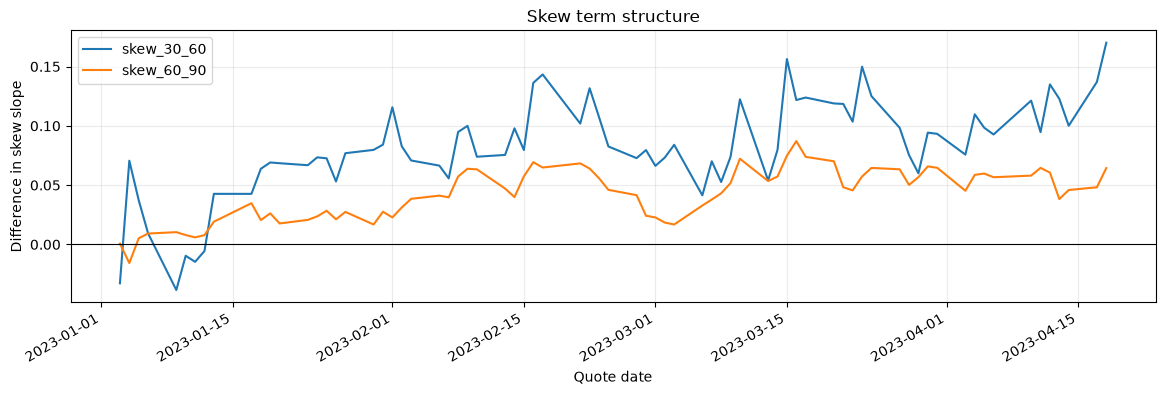

In [6]:
skew_levels = daily[[f"skew_{tenor}" for tenor in (30, 60, 90)]]
skew_changes = daily[[f"d_skew_{tenor}" for tenor in (30, 60, 90)]]
display(skew_levels.corr().rename_axis("level").rename_axis("level", axis=1))
display(skew_changes.corr().rename_axis("daily change").rename_axis("daily change", axis=1))

fig, ax = plt.subplots(figsize=(14, 4))
for column in ("skew_30_60", "skew_60_90"):
    ax.plot(daily["quote_date"], daily[column], label=column)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="Skew term structure", xlabel="Quote date", ylabel="Difference in skew slope")
ax.legend()
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.show()

## Skew, ATM volatility, and 25-delta risk reversal

Check contemporaneous relationships between 30D skew changes and 30D ATM-volatility changes, and between 30D skew level and 30D downside RR25. Each correlation uses only dates where both values are observed; report the paired sample size. These are descriptive checks, not forecasting tests.

In [7]:
pairs = {
    "30D skew change vs 30D ATM IV change": (daily["d_skew_30"], daily["d_atm_iv_30"]),
    "30D skew level vs 30D RR25": (daily["skew_30"], daily["rr25_30"]),
}
correlation_rows = []
for label, (x, y) in pairs.items():
    paired = pd.concat([x, y], axis=1).dropna()
    correlation_rows.append({"comparison": label, "n": len(paired), "correlation": paired.iloc[:, 0].corr(paired.iloc[:, 1])})
pd.DataFrame(correlation_rows).set_index("comparison")

,n,correlation
comparison,,
30D skew change vs 30D ATM IV change,72,0.176145
30D skew level vs 30D RR25,72,0.859919


## QC availability

Count valid observations by tenor and metric. A value counts as usable here only when its own QC flag is true and the value is finite, matching the masking performed in the daily builder. `coverage` is relative to all quote dates in the loaded file.

In [8]:
qc_definitions = {
    "skew": ("atm_skew_slope", "slope_valid"),
    "rr25": ("rr25_downside", "rr25_valid"),
    "atm_iv": ("atm_iv", "atm_valid"),
}
n_dates = metrics_long["quote_date"].nunique()
qc_rows = []
for tenor in (30, 60, 90):
    tenor_rows = metrics_long.loc[metrics_long["target_days"].eq(tenor)].copy()
    for metric, (value_column, flag_column) in qc_definitions.items():
        values = pd.to_numeric(tenor_rows[value_column], errors="coerce")
        valid = tenor_rows[flag_column].eq(True).fillna(False) & np.isfinite(values)
        count = int(valid.sum())
        qc_rows.append({
            "metric": metric, "tenor": tenor, "valid_count": count,
            "unavailable_count": n_dates - count,
            "coverage": count / n_dates if n_dates else np.nan,
        })
qc_summary = pd.DataFrame(qc_rows).set_index(["metric", "tenor"])
qc_summary.style.format({"coverage": "{:.1%}"})

,,valid_count,unavailable_count,coverage
metric,tenor,,,
skew,30,73,0,100.0%
rr25,30,72,1,98.6%
atm_iv,30,73,0,100.0%
skew,60,73,0,100.0%
rr25,60,73,0,100.0%
atm_iv,60,73,0,100.0%
skew,90,73,0,100.0%
rr25,90,73,0,100.0%
atm_iv,90,73,0,100.0%


## Read the results before choosing a model

Use the plots, distribution summaries, autocorrelations, and QC coverage together. In particular, compare persistence in skew levels with persistence in daily changes, and check whether apparent tenor relationships are supported by enough paired observations. No forecast target or model is specified here.